In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 39071)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 30117)

# #### Device() ####
# device = cuda:1

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:1)
# edge_attr                (32464, 16)              Tensor (cuda:1)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:1)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [2]:
print('hi')

hi


In [3]:
from modules.layers import Dims, SetPooling, Sequential
from modules.model import Encoder, Latent
from modules.utils import build_hidden_dims, cloneable, clone_or_init, input_to_dict, dict_summary
import torch
import torch.nn as nn
import torch.nn.functional as F

# typing
from modules.data import GraphDataset
from modules.norm import Normalizer
from torch import Tensor
from torch_geometric.data import Data
from typing import Literal, Union

In [4]:
@cloneable
class MultiLatentModel(nn.Module):
    def __init__(
        self,
        dataset: GraphDataset, # dims
        embed_dim: int | None = None, # dims
        head_dim: int | None = None,  # dims
        num_heads: int = 1,  # dims
        method: Literal['node','set'] = 'node', # dims, encoder; twin removed for now

        # layers
        norm_class: Normalizer | None = None, # encoder
        encoder_class: nn.Module | type[nn.Module] | None = None, # encoder
        pooling_class: SetPooling | type[SetPooling] = SetPooling, # encoder, latent
        mlp: bool | nn.Module = False, # latent
        variational: bool | nn.Module = False,  # latent

        # new layer params
        hidden_dims: int | list[int] | None = None, 
        act_fn: nn.Module | None = None, 
        norm_fn: Literal['batch','layer'] | None = None, 
        dropout: float | None = None,
        end_fn: bool | nn.Module = False,

        # kwargs
        norm_kwargs: dict | None = None, # encoder
        pooling_kwargs: dict | None = None, # encoder, latent
    ):
        super().__init__()
        norm_kwargs = {} if norm_kwargs is None else norm_kwargs
        pooling_kwargs = {} if pooling_kwargs is None else pooling_kwargs

        # get dims
        self.dims = Dims(
            dataset=dataset,
            embed_dim=embed_dim, head_dim=head_dim, num_heads=num_heads,
            method=method
        )

        # build hidden_dims from Dims
        self.hidden_dims = build_hidden_dims(self.dims.embed_dim, hidden_dims)

        # common encoder
        self.encoder = Encoder(
            dims=self.dims, method=method,
            norm_class=norm_class, encoder_class=encoder_class, pooling_class=pooling_class,
            hidden_dims=self.hidden_dims, act_fn=act_fn, norm_fn=norm_fn, dropout=dropout, end_fn=end_fn,
            norm_kwargs=norm_kwargs, pooling_kwargs=pooling_kwargs
        )
        
        # ae layers
        self.latent_ae = Latent(
            dims=self.dims,
            mlp=mlp, pooling_class=pooling_class, variational=variational,
            hidden_dims=self.hidden_dims, act_fn=act_fn, norm_fn=norm_fn, dropout=dropout, end_fn=end_fn,
            pooling_kwargs=pooling_kwargs
        )

        self.decoder = Sequential(
                in_channels=self.dims.embed_dim,
                out_channels=self.dims.num_nodes,
                layer_class=nn.Linear,
                hidden_dims=self.hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                dropout=dropout,
                end_fn=False, # no final layer, output raw logits
        )

        # cl layers
        self.latent_cl = Latent(
            dims=self.dims,
            mlp=mlp, pooling_class=pooling_class, variational=variational,
            hidden_dims=self.hidden_dims, act_fn=act_fn, norm_fn=norm_fn, dropout=dropout, end_fn=end_fn,
            pooling_kwargs=pooling_kwargs
        )

        self.classifier = Sequential(
                in_channels=self.dims.embed_dim,
                out_channels=self.dims.num_classes,
                layer_class=nn.Linear,
                hidden_dims=self.hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                dropout=dropout,
                end_fn=False, # no final layer, output raw logits
        )

    def _forward_head(self, data:dict, latent:nn.Module, out_layer:nn.Module, need_weights:bool):
        d = data.copy()

        # reset layer_outs
        if need_weights: 
            d['layer_outs'] = {} 

        # forward pass
        out = latent(d, need_weights)
        out = out_layer(out, return_dict=need_weights, return_attention_weights=need_weights)

        # extract x
        if isinstance(out, Tensor):
            x = out
            out = None
        else:
            out = input_to_dict(out)
            x = out.pop('x')

        return x, out, d

    def _merge_data(self, data1:dict, data2:dict, suffix:str=''):
        for key2, val2 in list(data2.items()):
            if key2 not in data1:
                data1[f'{key2}{suffix}'] = val2
        return data1
    
    def init_with_loader(self, loader): # pass loader to Encoder -> Norm
        if callable(getattr(self.encoder.norm, 'init_with_loader', None)):
            self.encoder.norm.init_with_loader(loader)

    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False):
        # get common encoding
        data:dict = self.encoder(input, need_weights)
        data['theta'] = self.encoder.norm.theta.view(1, -1) if hasattr(self.encoder.norm, 'theta') else None

        # autoencoder
        x_t_pred, ae_out, data_ae = self._forward_head(data, self.latent_ae, self.decoder, need_weights)
        x_pred = self.encoder.norm.inverse_transform(x_t_pred, data.get('libsize', None))
            
        # classifier
        y_logits, cl_out, data_cl = self._forward_head(data, self.latent_cl, self.classifier, need_weights)

        # format output
        data = self._merge_data(data, data_ae, suffix='_ae')
        data = self._merge_data(data, data_cl, suffix='_cl')

        x_out_shape = x_pred.shape
        data['x'] = input_to_dict(input)['x'].float().view(x_out_shape)
        data['x_t'] = data['x_t'].view(x_out_shape)

        data['x_t_pred'] = x_t_pred
        data['x_pred'] = x_pred

        data['y_logits'] = y_logits
        data['y_prob'] = y_logits.softmax(dim=-1)
        data['y_pred'] = y_logits.argmax(dim=-1)

        if need_weights:
            data['layer_outs']['lp_ae'] = data_ae['layer_outs'].get('lp', None)
            data['layer_outs']['lp_cl'] = data_cl['layer_outs'].get('lp', None)
            data['layer_outs']['out_ae'] = ae_out
            data['layer_outs']['out_cl'] = cl_out

        return data

In [5]:
from modules.norm import LogCounts
from modules.layers import AttentionSetPooling, MultiheadSetPooling
from modules.train import Loader
from modules.utils import dict_summary

In [6]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    num_heads = 2,
    method = 'set',
    
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = MultiheadSetPooling,
    variational = True,

    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True},
    pooling_kwargs = {'aggregate':'concat'}
)

model.init_with_loader(loader)
out = model(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)

# x                        (64, 4373)               Tensor (cuda:1)
# x_t                      (64, 4373)               Tensor (cuda:1)
# libsize                  (64,)                    Tensor (cuda:1)
# libscale                 ()                       Tensor (cuda:1)
# batch_size               64                       int
# num_nodes                4373                     int
# theta                    (1, 4373)                Tensor (cuda:1)
# z_mu_ae                  (64, 128)                Tensor (cuda:1)
# z_logvar_ae              (64, 128)                Tensor (cuda:1)
# z_mu_cl                  (64, 128)                Tensor (cuda:1)
# z_logvar_cl              (64, 128)                Tensor (cuda:1)
# x_t_pred                 (64, 4373)               Tensor (cuda:1)
# x_pred                   (64, 4373)               Tensor (cuda:1)
# y_logits                 (64, 5)                  Tensor (cuda:1)
# y_prob                   (64, 5)                  Tensor (cuda:1)
# y_

---

In [7]:
model._orig_kwargs

{'dataset': GraphDataset(1172),
 'embed_dim': 128,
 'head_dim': None,
 'num_heads': 2,
 'method': 'set',
 'norm_class': modules.norm.LogCounts,
 'encoder_class': torch.nn.modules.linear.Linear,
 'pooling_class': modules.layers.MultiheadSetPooling,
 'mlp': False,
 'variational': True,
 'hidden_dims': 1,
 'act_fn': torch.nn.modules.activation.ReLU,
 'norm_fn': 'layer',
 'dropout': None,
 'end_fn': False,
 'norm_kwargs': {'libnorm': True, 'znorm': True, 'learnable': True},
 'pooling_kwargs': {'aggregate': 'concat'}}

In [8]:
from modules.train import Trainer

In [9]:
class MultiTrainerStage():
    def __init__(self, name:str, trainer:Trainer, num_epochs:int|None=None, train:str|list[str]|None=None):
        self.name = name
        self.trainer = trainer
        self.num_epochs = num_epochs

        # ensure list
        if isinstance(train, str) or train is None:
            self.train = [train] if train is not None else []
        else: 
            self.train = list(train)

    def apply(self, model:nn.Module):
        # freeze all params
        for param in model.parameters():
            param.requires_grad = False

        # unfreeze specified modules
        for module_name in self.train:
            if not hasattr(model, module_name):
                raise AttributeError(f"[Stage {self.name}] model has no submodule '{module_name}'")
            
            module: nn.Module = getattr(model, module_name)
            for param in module.parameters():
                param.requires_grad = True


In [10]:
class MultiTrainer(Trainer):
    def __init__(self, stages: list[MultiTrainerStage]):
        self.stages = stages
        self._orig_kwargs = {s.name: getattr(s.trainer, "_orig_kwargs", type(s.trainer).__name__) for s in stages}

    def run(
        self,
        model: nn.Module,
        loader: Loader,
        num_epochs: int,
        report_metrics: str | list[str] | None = None,
        verbose: bool = False,
    ):
        # init outputs to match Trainer behavior
        self.dev_metrics = {}
        self.test_metrics = {}
        self.test_values = {}
        self.test_report = ''

        # carry-forward model across stages
        cur_model = model

        for stage in self.stages:
            # freeze/train modules as specified    
            stage.apply(cur_model)

            # run stage
            stage.trainer.run(
                model = cur_model,
                loader = loader,
                num_epochs = stage.num_epochs if stage.num_epochs is not None else num_epochs,
                report_metrics = report_metrics,
                verbose = verbose,
            )

            # aggregate dev_metrics
            for epoch, phases in stage.trainer.dev_metrics.items():
                self.dev_metrics.setdefault(epoch, {})
                for phase, metrics in phases.items(): # phase: 'train' or 'val'
                    self.dev_metrics[epoch].setdefault(phase, {})                    
                    self.dev_metrics[epoch][phase].update({f"{k}_{stage.name}": v for k,v in metrics.items()})

            # aggregate test_metrics, test_values, test_report
            tm = getattr(stage.trainer, "test_metrics", {}) or {}
            tv = getattr(stage.trainer, "test_values", {}) or {}

            for k,v in tm.items():
                self.test_metrics[f"{k}_{stage.name}"] = v

            for k,v in tv.items():
                self.test_values[f"{k}_{stage.name}"] = v

            # carry forward trained model
            cur_model = stage.trainer.model

        # final outputs
        self.model = cur_model

        self.test_report = ' | '.join(
            f'{stage.name}: {stage.trainer.test_report}'
            for stage in self.stages
            if getattr(stage.trainer, 'test_report', None)
        )


---

In [11]:
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss

In [12]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    method = 'node',
    
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    variational = False,

    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 

    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True},
)

ae_stage = MultiTrainerStage(
    name = 'ae',
    train = ['encoder', 'latent_ae', 'decoder'],
    trainer = ReconstrTrainer(
        lr=1e-3, 

        trainer_norm_class=LogCounts,
        early_stop=True,
        stop_metric='mae',

        kw_keys={'x':'x', 'mu':'x_pred', 'theta':'theta'},
        metric_keys={'pred':'mu', 'target':'x'},
        loss_class=NBLoss
    )
)

cl_stage = MultiTrainerStage(
    name = 'cl',
    train = ['latent_cl', 'classifier'],
    trainer = ClassifTrainer(
        lr=1e-3, 

        early_stop=True,
        stop_metric='accuracy',
        stop_kwargs={'mode':'max'},

        kw_keys={'input':'y_logits', 'target':'y'},
        metric_keys={'pred':'input', 'target':'target'},
        loss_class=nn.CrossEntropyLoss
    )
)

trainer = MultiTrainer(
    stages = [ae_stage, cl_stage]
)

In [13]:
# trainer.run(
#     model=model,
#     loader=loader,
#     num_epochs=300,
#     report_metrics=['loss','kld','nb','mae', 'accuracy'],
#     verbose=True
# )

---

In [14]:
from modules.train import Experiment, grid
from modules.loss import KLDLoss, MultiLoss
from functools import partial

In [15]:
model_template = partial(
    MultiLatentModel,
    dataset = dataset,
    embed_dim = 128,
    # num_heads = 4,

    # method = 'node',
    
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,

    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer',
    # dropout = 0.3,

    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True},
    # pooling_kwargs= {'aggregate':'concat'}
)

model_grid = grid(
    model_template,
    method = ['node','set'],
)

ae_stage = MultiTrainerStage(
    name = 'ae',
    train = ['encoder', 'latent_ae', 'decoder'],
    trainer = ReconstrTrainer(
        lr=1e-3, 

        trainer_norm_class=LogCounts,
        early_stop=True,
        stop_metric='mae',

        kw_keys=('x','x_pred','theta','z_mu_ae','z_logvar_ae'),
        metric_keys={'pred':'x_pred', 'target':'x'},
        
        loss_class=MultiLoss,
        loss_kwargs = {
        'loss_classes': [NBLoss, KLDLoss],
        'loss_weights': [1.0, 1e-4],
        'loss_inputs': [
            {'x':'x', 'mu':'x_pred', 'theta':'theta'},
            {'mu':'z_mu_ae', 'logvar':'z_logvar_ae'}
        ]
    },
    )
)

cl_stage = MultiTrainerStage(
    name = 'cl',
    train = ['latent_cl', 'classifier'],
    trainer = ClassifTrainer(
        lr=1e-3, 

        early_stop=True,
        stop_metric='accuracy',
        stop_kwargs={'mode':'max'},

        kw_keys={'input':'y_logits', 'target':'y'},
        metric_keys={'pred':'input', 'target':'target'},
        loss_class=nn.CrossEntropyLoss,
        # loss_kwargs={'label_smoothing':0.1}
    )
)

trainer = MultiTrainer(
    stages = [ae_stage, cl_stage]
)

expt = Experiment(
    num_trials=30, # scVI: 5 trials
    num_epochs=300, # scVI: 200 epochs
    dataset=dataset,
    device=device,
    batch_size=128
)

# expt.add_config(
#     name = 'multitrainer_test',
#     model = model,
#     trainer = trainer,
# )

expt.add_grid(
    model_grid = model_grid,
    trainer_grid = trainer
)

In [16]:
expt.configs

{'methodNode': <__main__.MultiTrainer at 0x7fe1d1fd1950>,
 'methodSet': <__main__.MultiTrainer at 0x7fe1d1fd1950>}

In [31]:
expt.run_experiment(
    'multitrainer_30',
    report_metrics=['loss','kld','nb','mae', 'accuracy', 'precision', 'f1'],
    # save_model=True,
    save_csv=True,
    save_params=True,
    save_values=True,
    verbose=False,
)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

---

In [25]:
from modules.viz import MultiExperiment, devplot, metric_x_point

In [26]:
viz = MultiExperiment(
    experiment_dirs=['output/2026-01-08_05h35m39s_multitrainer_viz_test'],
    keys = ['method'],
    out_dir='experiments/multitrainer_viz_test/'
)

Avoided overwriting 6 files. Call self.avoided_overwrite to see list, or run with overwrite=True to overwrite.


In [27]:
viz.keys

['method']

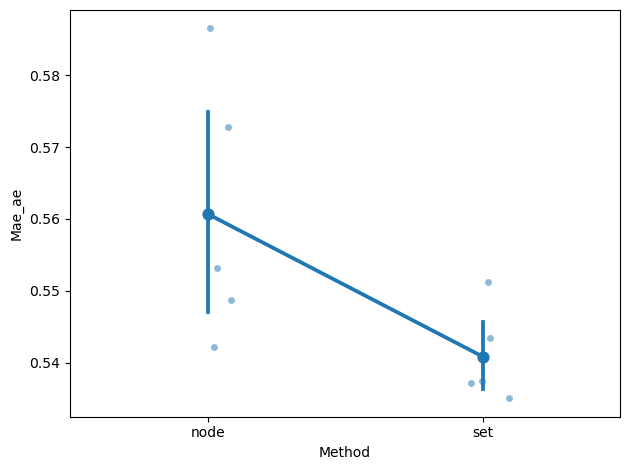

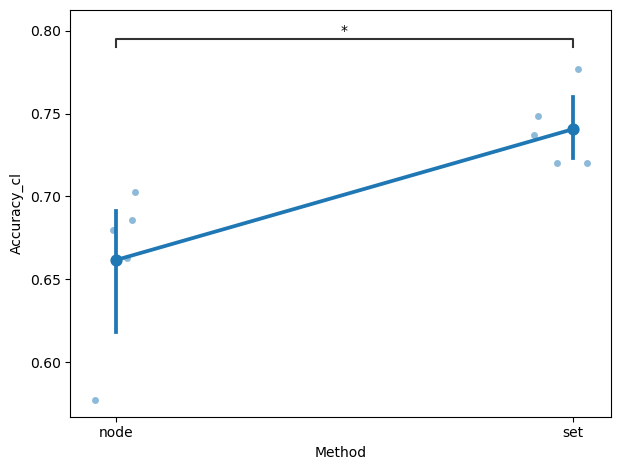

In [28]:
metric_x_point(
    df=viz.test,
    cols=viz.keys,
    metrics=['mae_ae','accuracy_cl'],
    # hue=True,
    strip=True
)

In [29]:
metric_x_point(
    df=viz.test,
    cols=viz.keys,
    metrics=['mae_ae','accuracy_cl'],
    hue=True,
    strip=True
)

In [30]:
# figs = devplot(dev=expt.dev_df, summary=expt.summary)